<a href="https://colab.research.google.com/github/sevaradevoloper/machine-learning-class-work/blob/main/linearmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
# USE house pricing

In [42]:
!pip install opendatasets legacy-cgi

In [43]:
import opendatasets as od


In [44]:
od.download("https://www.kaggle.com/datasets/praveenobulreddy/usa-housing-dataset")

Skipping, found downloaded files in "./usa-housing-dataset" (use force=True to force download)


In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error,root_mean_squared_error,mean_absolute_error

In [46]:
df = pd.read_csv("/content/usa-housing-dataset/USA_Housing.csv")


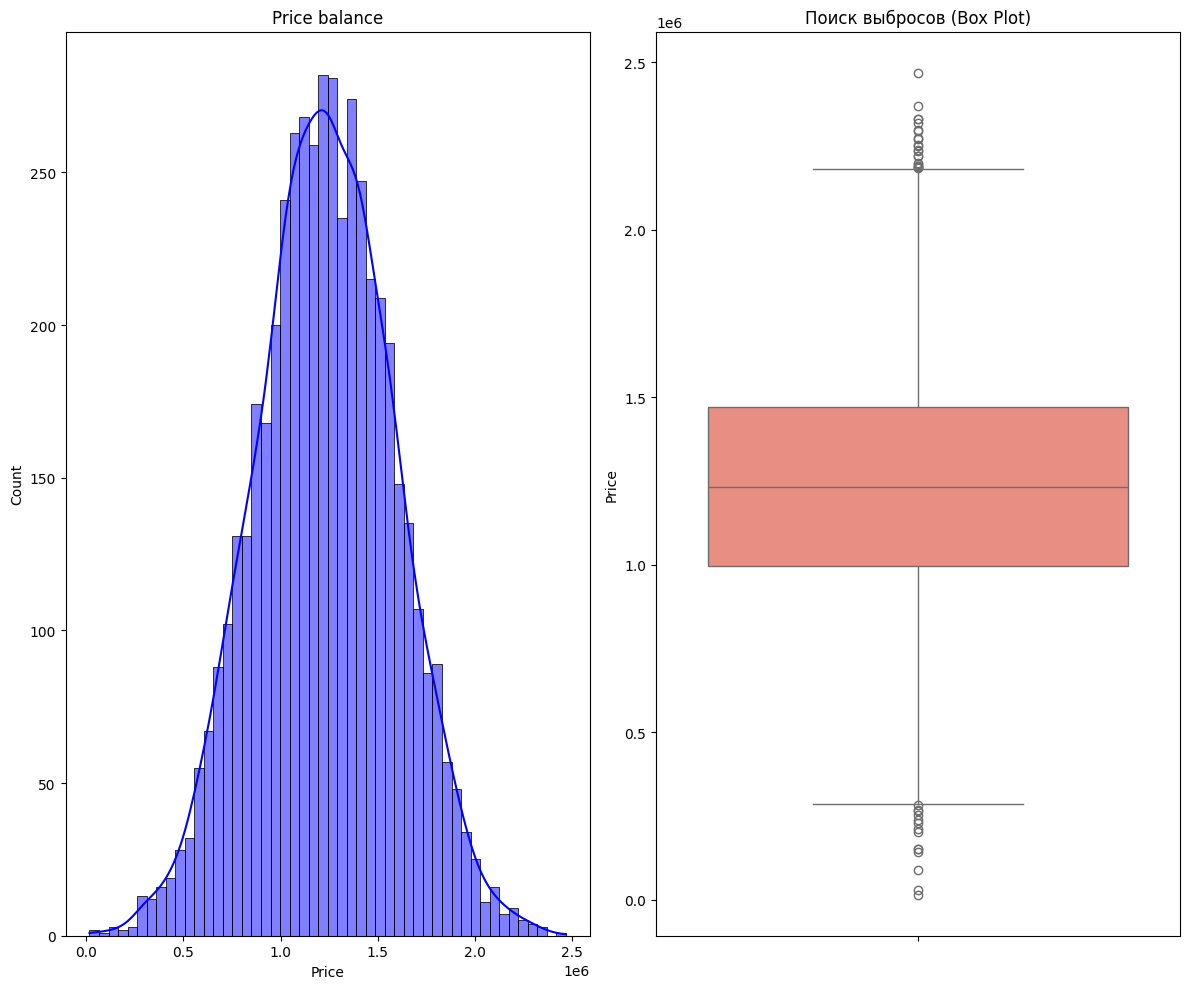

,Price
count,5.000000e+03
mean,1.232073e+06
std,3.531176e+05
min,1.593866e+04
25%,9.975771e+05
50%,1.232669e+06
75%,1.471210e+06
max,2.469066e+06


In [47]:
fig,ax = plt.subplots(1,2,figsize=(12,10))
sns.histplot(df['Price'],kde=True,color='blue',bins=50 ,ax=ax[0])
ax[0].set_title('Price balance')
ax[1].set_xlabel('Price')

sns.boxplot(y=df['Price'], color='salmon', ax=ax[1])
ax[1].set_title('Поиск выбросов (Box Plot)')
ax[1].set_xlabel('')

plt.tight_layout()
plt.show()

df["Price"].describe()

In [48]:
df.columns.tolist()

['Avg. Area Income',
 'Avg. Area House Age',
 'Avg. Area Number of Rooms',
 'Avg. Area Number of Bedrooms',
 'Area Population',
 'Price',
 'Address']

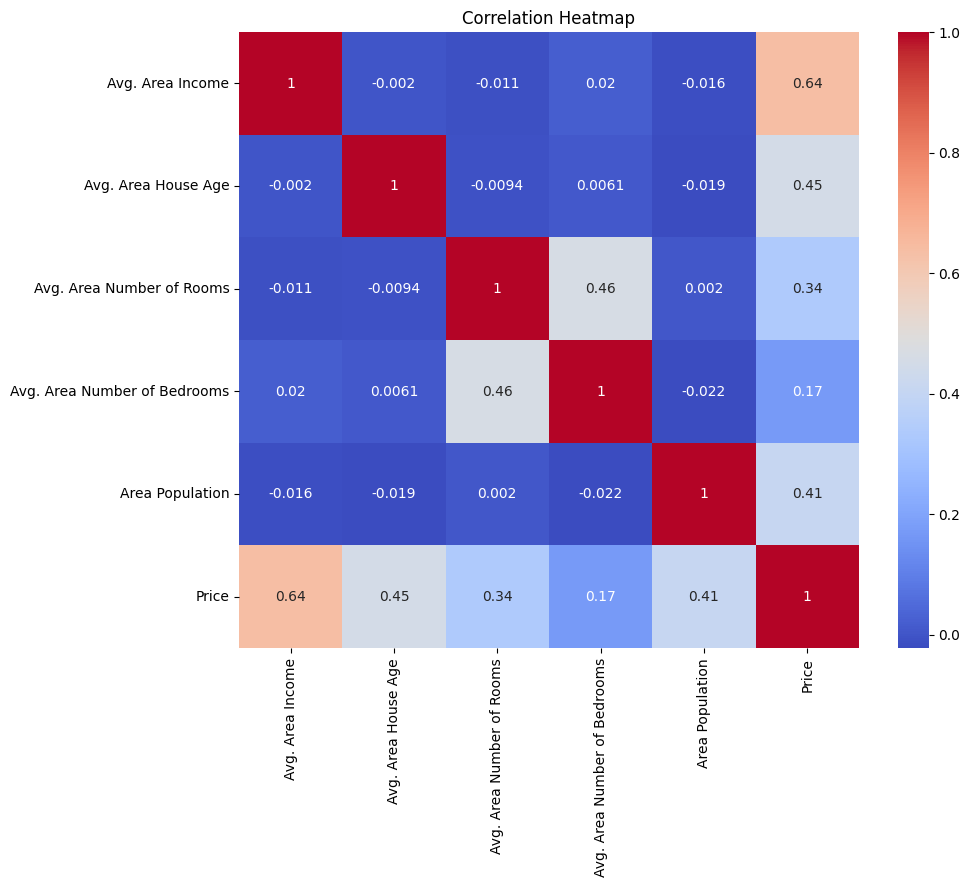

In [49]:
df_num = df.drop(columns='Address',axis=1)

plt.figure(figsize=(10,8))
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

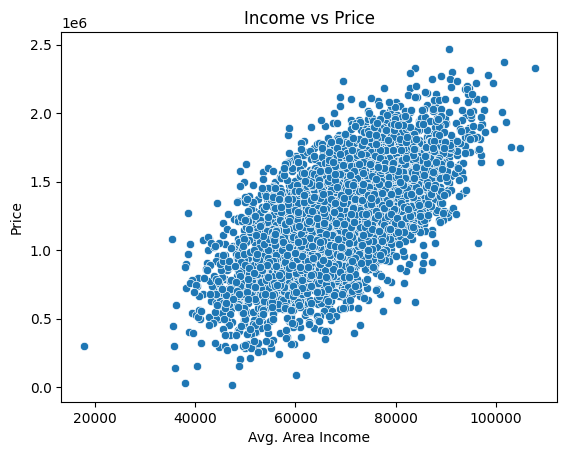

In [50]:
sns.scatterplot(data=df, x='Avg. Area Income', y='Price')
plt.title("Income vs Price")
plt.show()

In [51]:
X = df.drop(['Price','Address'],axis=1)
y = df['Price']
print(X.shape)
print(y.shape)


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


(5000, 5)
(5000,)


In [52]:
# linear regression

In [53]:
model = LinearRegression()
model.fit(X_train,y_train)
# w (weights) — har bir feature uchun
print("Weights (w):")
for feature, w in zip(X.columns, model.coef_):
    print(f"  {feature}: {w:.2f}")

# b (bias / intercept)
print(f"\nBias (b): {model.intercept_:.2f}")



Weights (w):
  Avg. Area Income: 21.65
  Avg. Area House Age: 164666.48
  Avg. Area Number of Rooms: 119624.01
  Avg. Area Number of Bedrooms: 2440.38
  Area Population: 15.27

Bias (b): -2635072.90


In [54]:
# metrics
def show_all_metrics(y_true,y_pred):
  mae = mean_absolute_error(y_true,y_pred)
  mse = mean_squared_error(y_true,y_pred)
  rmse = root_mean_squared_error(y_true,y_pred)
  r2 = r2_score(y_true,y_pred)

  print("======Metrics====")
  print(f"MAE : {mae:.4f}")
  print(f"MSE : {mse:.4f}")
  print(f"RMSE :{rmse:.4f}")
  print(f"R2 : {r2:.4f}")

y_pred = model.predict(X_test)

show_all_metrics(y_test,y_pred)

======Metrics====
MAE : 80879.0972
MSE : 10089009300.8945
RMSE :100444.0606
R2 : 0.9180


In [55]:
import numpy as np

# Ma'lumotni numpy array qilamiz (scaled train)
X_gd = np.array(X_train_scaled)      # (4000, 5)
y_gd = np.array(y_train).reshape(-1) # (4000,)

n, n_features = X_gd.shape

# Boshlang'ich qiymatlar
w = np.zeros(n_features)   # har feature uchun 0
b = 0.0
alpha = 0.01               # learning rate
epochs = 100               # necha marta takrorlash

# Har qadamni saqlash uchun (vizual uchun!)
history = []

for epoch in range(epochs):
    # 1. Bashorat
    y_pred = np.dot(X_gd, w) + b

    # 2. Xato
    error = y_pred - y_gd

    # 3. Loss (MSE)
    loss = np.mean(error ** 2)

    # 4. Gradientlar
    dw = (2/n) * np.dot(X_gd.T, error)
    db = (2/n) * np.sum(error)

    # 5. Yangilash
    w = w - alpha * dw
    b = b - alpha * db

    # 6. Saqlash (vizual uchun)
    history.append({
        "epoch": epoch,
        "loss": float(loss),
        "w": w.tolist(),
        "b": float(b)
    })

print(f"Oxirgi loss: {history[-1]['loss']:.2f}")
print(f"Oxirgi w: {w}")
print(f"Oxirgi b: {b:.2f}")

NameError: name 'X_train_scaled' is not defined